In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys
import html as html_lib
from IPython.display import HTML, display as ipy_display
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

import torch
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_trainer.model_utils import SparseAutoencoder
from sae_trainer.feature_tracer_utils import FeatureTracer, TraceConfig
from sae_trainer.feature_tracer_eval_utils import top_n_feats_by_hits_count, top_n_feats_by_act_mass, prompt_x_feature_heatmap, feature_token_position_profile, top_m_feature_coactivation, render_feature_card, plot_feature_umap, plot_inter_feature_similarity

/Users/alyssagardiner/src/sae_trainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
layer_idx = 6
dataset_name = 'openwebtext'
model_name_simple = "gpt2" # Either gpt2 or qwen

if model_name_simple == "gpt2":
    model_name = "gpt2"
elif model_name_simple == "qwen":
    model_name = "Qwen/Qwen2-0.5B-Instruct"
else:
    raise ValueError(f"Invalid model name: {model_name_simple}. Expected either 'gpt2' or 'qwen'.")
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm = AutoModelForCausalLM.from_pretrained(model_name).to(device).eval()

# Load SAE checkpoint — pick whichever layer you want to analyse (3, 6, 9, or 11)
ckpt = torch.load(root / f"sae_{model_name_simple}_{dataset_name}_layer{layer_idx}.pt", map_location=device)
sae = SparseAutoencoder(d_in=ckpt["d_in"], d_latent=ckpt["d_latent"], normalize_decoder=True).to(device)
sae.load_state_dict(ckpt["model_state"])
sae.eval()

SparseAutoencoder(
  (encoder): Linear(in_features=768, out_features=6144, bias=True)
  (decoder): Linear(in_features=6144, out_features=768, bias=False)
)

In [5]:
# 4) Tracer config — layer_idx MUST match the checkpoint loaded above
cfg = TraceConfig(
    layer_idx=layer_idx,
    topk_per_token=8,
    min_activation=0.01,
    max_new_tokens=10,
    do_sample=True,
    temperature=0.7,
)
tracer = FeatureTracer(llm, tokenizer, sae, device, cfg)

In [ ]:
from datasets import load_dataset

n_train_docs = 4000 # cfg.max_batches * cfg.collection_batch_size

ds = load_dataset("openwebtext", split="train", streaming=True)
# Exclude training data
ds = ds.skip(n_train_docs)

summaries = tracer.trace_prompts_from_iterable_dataset(ds, max_prompts_to_trace=100)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Skylion007/openwebtext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


In [8]:
# Score all features (calls compute_feature_embeddings internally)
scores = tracer.feature_specificity_scores()
display(scores.head(20))

# Or run embedding + scoring separately if you want to reuse the embeddings
#embeddings = tracer.compute_feature_embeddings(
#    feature_ids=tracer.top_features(50)["feature_id"].tolist(),
#    contexts_per_feature=30,
#)
#scores = tracer.feature_specificity_scores(feature_embeddings=embeddings)
#display(scores.head(20))


,feature_id,hits,n_prompts,mean_activation,specificity,specificity_vs_baseline
0,771,18,10,6.665462,0.152207,0.074221
1,2389,11,11,6.329748,0.151862,0.073875
2,1291,6,6,5.682490,0.140889,0.062903
3,2051,21,19,5.380710,0.127581,0.049594
4,1719,18,16,6.030523,0.125419,0.047433
5,1565,11,9,5.835887,0.124521,0.046535
6,5973,23,17,6.560475,0.116864,0.038877
7,4024,7,7,5.312801,0.116479,0.038492
8,81,12,9,5.405470,0.114036,0.036049
9,3268,7,7,5.837530,0.113999,0.036012


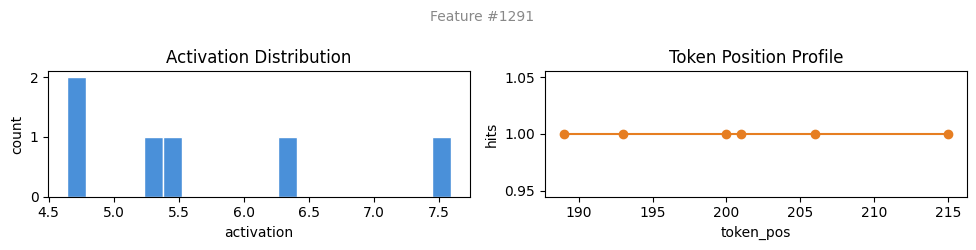

In [11]:
render_feature_card(1291, tracer)

In [27]:
display(scores.tail(20))

,feature_id,hits,mean_activation,specificity,specificity_vs_baseline
2001,6833,1,1.537111,NaN,NaN
2002,3905,1,1.534254,NaN,NaN
2003,5410,1,1.512581,NaN,NaN
2004,7037,1,1.508000,NaN,NaN
2005,3107,2,1.298776,NaN,NaN
2006,5610,1,1.668076,NaN,NaN
2007,4326,1,1.635404,NaN,NaN
2008,6208,1,1.251771,NaN,NaN
2009,3620,1,1.554100,NaN,NaN
2010,5894,1,1.471671,NaN,NaN


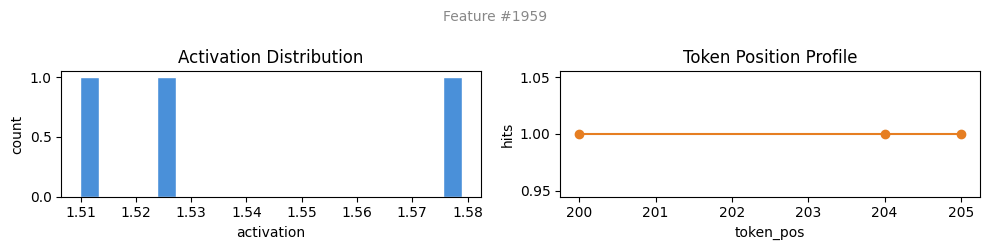

In [28]:
render_feature_card(1959, tracer)

/Users/alyssagardiner/src/sae_trainer/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


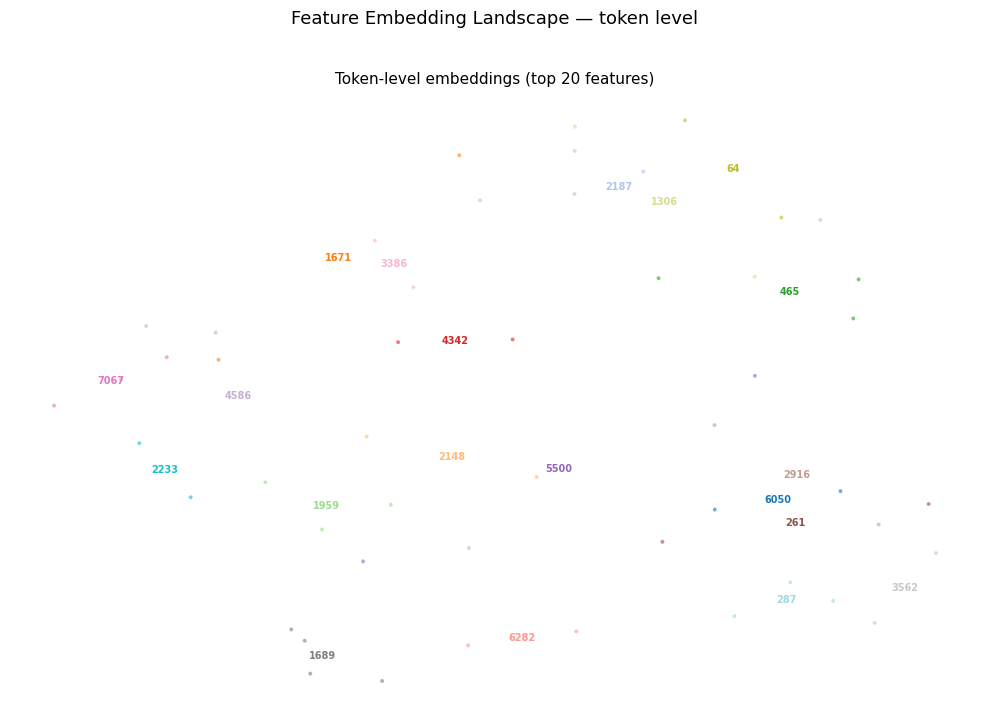

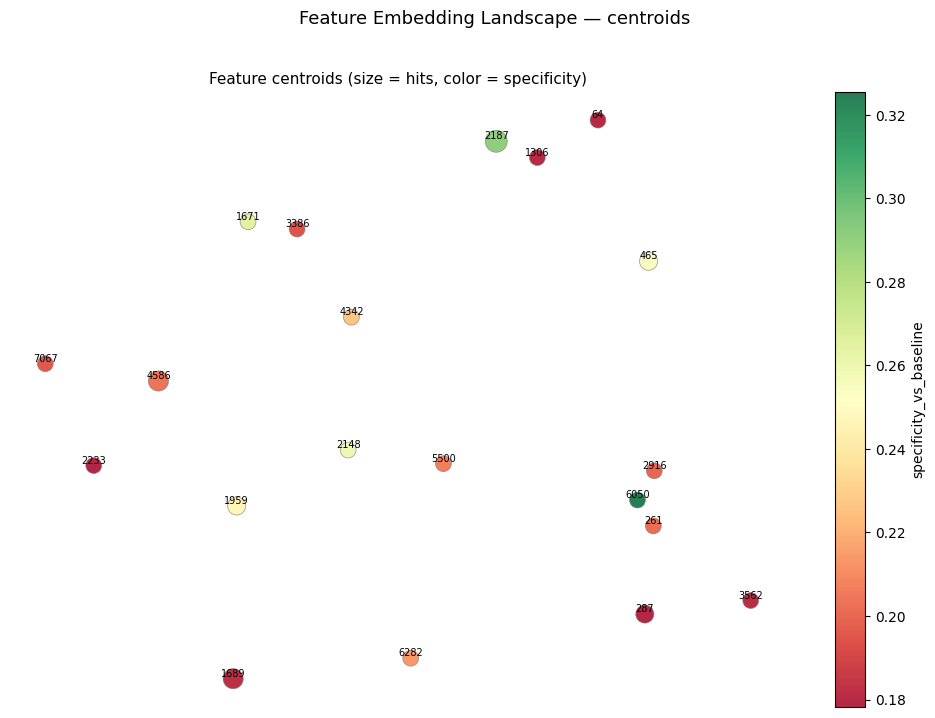

In [29]:
# Note: can't test this yet, can't install umap
plot_feature_umap(tracer, top_n=20)

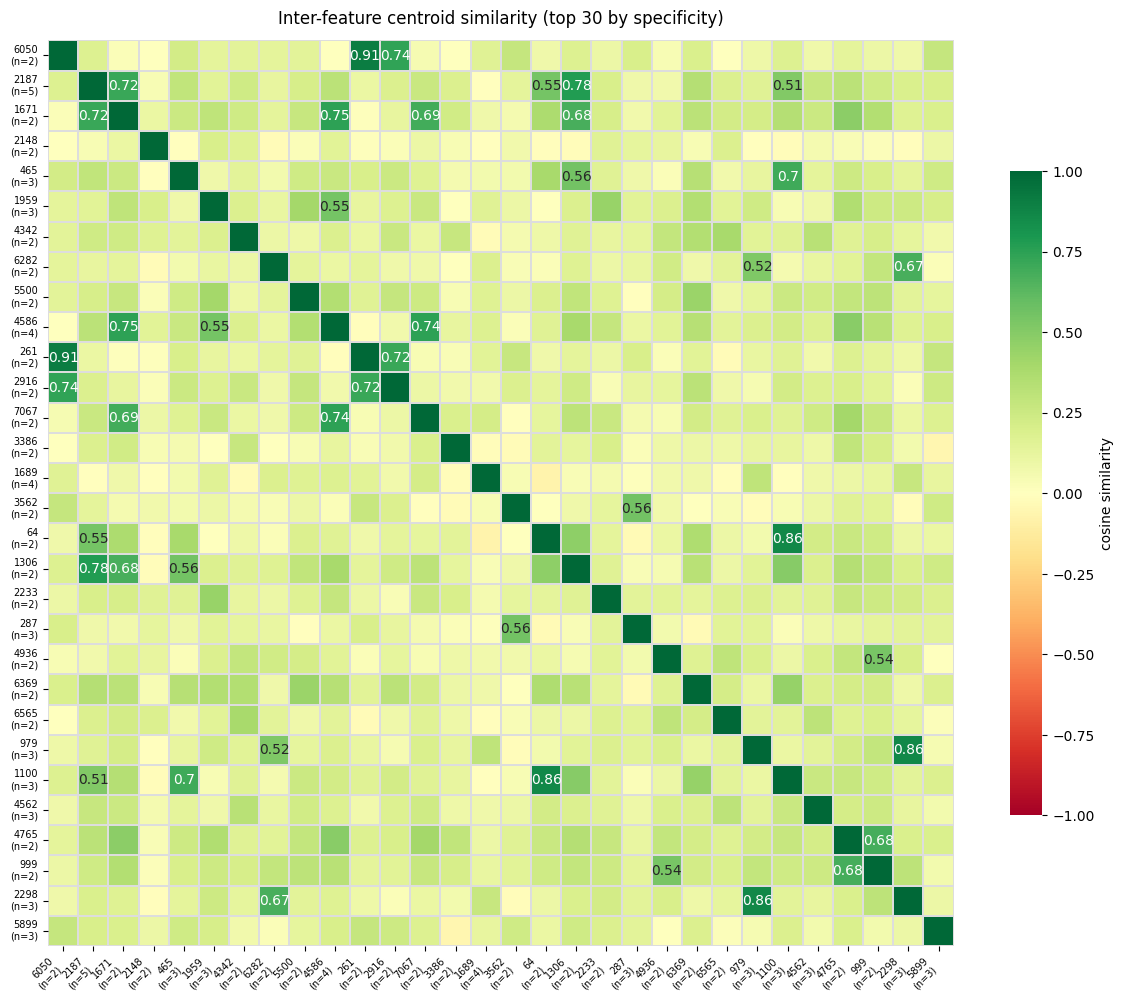


Potentially redundant pairs (cosine_sim >= 0.5):


,feature_a,feature_b,cosine_sim
0,6050,261,0.9127
19,979,2298,0.8620
17,64,1100,0.8612
4,2187,1306,0.7782
6,1671,4586,0.7463
14,4586,7067,0.7434
1,6050,2916,0.7380
15,261,2916,0.7162
2,2187,1671,0.7152
10,465,1100,0.7007


(array([[ 1.00000012e+00,  1.75731689e-01,  2.62811743e-02,
          3.41273844e-05,  2.22744405e-01,  1.40322506e-01,
          1.44840568e-01,  1.34369612e-01,  1.47018045e-01,
          4.95906919e-04,  9.12692845e-01,  7.38024414e-01,
          5.08586094e-02,  4.60468233e-04,  1.56322926e-01,
          2.78171748e-01,  8.55238438e-02,  1.76758349e-01,
          9.73203480e-02,  2.01288685e-01,  4.43559885e-02,
          1.90520704e-01,  4.19935212e-04,  8.92715603e-02,
          1.76213592e-01,  8.41016620e-02,  1.38706625e-01,
          9.87461433e-02,  7.92053044e-02,  2.76548982e-01],
        [ 1.75731689e-01,  1.00000012e+00,  7.15206504e-01,
          3.90805975e-02,  2.92562604e-01,  1.55685201e-01,
          2.39423454e-01,  1.22343138e-01,  2.04726964e-01,
          3.13836753e-01,  1.08373374e-01,  1.87280476e-01,
          2.63470650e-01,  1.80757523e-01, -1.56604126e-03,
          1.36053860e-01,  5.53251863e-01,  7.78249979e-01,
          1.95373967e-01,  8.38276297e-

In [30]:
# Note: can't test this yet, can't install umap
plot_inter_feature_similarity(tracer)